In [1]:
from pathlib import Path

from caf.base import DVector, ZoningSystem
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from numpy.polynomial.polynomial import polyfit

plt.style.use(r'https://raw.githubusercontent.com/Transport-for-the-North/caf.viz/main/src/caf/viz/tfn.mplstyle')

In [2]:
output_dir = Path(r"I:\NorMITs NorCOM\Reporting\figs")

In [3]:
input_file = Path(r"I:\NorMITs NorCOM\Validation\v38\2021\2021_validation_v38.xlsx")

In [4]:
absolute_data = pd.read_excel(input_file, sheet_name="SUMMARY", header=[0, 1])

In [5]:
absolute_data.head()

LSOA2021 Expected Car Availability                 \
  Unnamed: 0_level_1                         1    2   3 Total   
0          E01000001                       555  243  40   838   
1          E01000002                       578  208  39   825   
2          E01000003                       826  169  22  1017   
3          E01000005                       375   92  12   479   
4          E01000842                       379  274  52   705   

  Resulting Car Availability                               
                           1          2         3   Total  
0                  389.54165  401.67148  48.78687   840.0  
1                  392.43970  388.22176  45.33854   826.0  
2                  530.46019  442.48851  42.05130  1015.0  
3                  278.34374  177.25791  23.39835   479.0  
4                  355.50771  305.80722  41.68507   703.0

In [6]:
dfs = []
r_squareds = []
slopes = []
intercepts = []
for j in range(1, 4):
    # get data to plot
    filtered = absolute_data[[("LSOA2021", "Unnamed: 0_level_1"), ("Expected Car Availability", j), ("Resulting Car Availability", j)]]
    filtered.columns = ["LSOA", "Expected", "Resulting"]

    # calculate line of best fit
    i, s = polyfit(filtered["Expected"], filtered["Resulting"], 1)

    # calculate r2
    r2 = filtered["Expected"].corr(filtered["Resulting"]) ** 2

    # calculate LOBF
    filtered["lobf"] = s * filtered["Expected"] + i

    # store all outputs
    dfs.append(filtered)
    intercepts.append(i)
    slopes.append(s)
    r_squareds.append(r2)

C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_4840\3497938195.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_4840\3497938195.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_4840\3497938195.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

Text(0, 0.5, 'Predicted Number of Households (Land Use)')

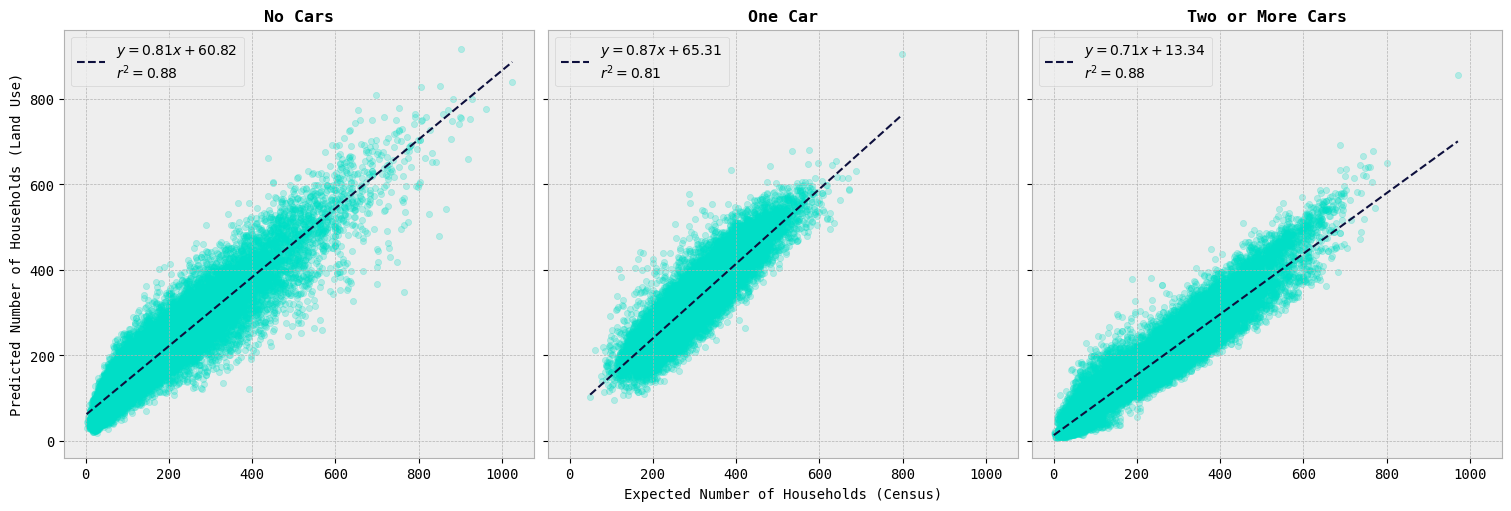

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(15, 5))

for ax, data, slope, intercept, rsq in zip(axes, dfs, slopes, intercepts, r_squareds):
    data.plot.scatter(x="Expected", y="Resulting", ax=ax, color="C1", alpha=0.25)
    data.iloc[[data["Expected"].idxmin(), data["Expected"].idxmax()]].plot.line(
        x="Expected", y="lobf", ax=ax, ls="--", color="C0", label=f"$y={slope:.2f}x+{intercept:.2f}$ \n$r^2={rsq:.2f}$"
    )
    ax.legend(loc="upper left")

axes[0].set_title("No Cars", weight="bold")
axes[1].set_title("One Car", weight="bold")
axes[2].set_title("Two or More Cars", weight="bold")

axes[0].set_xlabel("")
axes[2].set_xlabel("")
axes[1].set_xlabel("Expected Number of Households (Census)")
axes[0].set_ylabel("Predicted Number of Households (Land Use)")

In [8]:
fig.savefig(output_dir / "v38_households_2021.png")
plt.close()

In [9]:
for tab in ["MODEL SHARES", "NORTHERN SHARES"]:
    share_data = pd.read_excel(input_file, sheet_name=tab, header=[0, 1])

    dfs = []
    r_squareds = []
    slopes = []
    intercepts = []
    for col in ["No Cars", "1+ Cars", "1 Car", "2+ Cars"]:
        # get data to plot
        filtered = share_data[[("LSOA2021", "Unnamed: 0_level_1"), ("Expected Car Availability", col), ("Resulting Car Availability", col)]]
        filtered.columns = ["LSOA", "Expected", "Resulting"]
    
        # calculate line of best fit
        i, s = polyfit(filtered["Expected"], filtered["Resulting"], 1)
    
        # calculate r2
        r2 = filtered["Expected"].corr(filtered["Resulting"]) ** 2
    
        # calculate LOBF
        filtered["lobf"] = s * filtered["Expected"] + i
    
        # store all outputs
        dfs.append(filtered)
        intercepts.append(i)
        slopes.append(s)
        r_squareds.append(r2)

    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(10, 10))

    for ax, data, slope, intercept, rsq in zip(axes.ravel(), dfs, slopes, intercepts, r_squareds):
        data.plot.scatter(x="Expected", y="Resulting", ax=ax, color="C1", alpha=0.25)
        data.iloc[[data["Expected"].idxmin(), data["Expected"].idxmax()]].plot.line(
            x="Expected", y="lobf", ax=ax, ls="--", color="C0", label=f"$y={slope:.2f}x+{intercept:.2f}$ \n$r^2={rsq:.2f}$"
        )
        ax.legend(loc="upper left")
    
    axes[(0, 0)].set_title("No Cars", weight="bold")
    axes[(0, 1)].set_title("One or More Cars", weight="bold")
    axes[(1, 0)].set_title("One Car", weight="bold")
    axes[(1, 1)].set_title("Two or More Cars", weight="bold")
    
    axes[(0, 0)].yaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
    )
    axes[(0, 0)].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
    axes[(0, 0)].xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
    )
    axes[(0, 0)].xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
    
    axes[(0, 0)].set_xlim([0, 1])
    axes[(0, 0)].set_ylim([0, 1])
    
    fig.suptitle("Proportion of Households", weight="bold")

    fig.savefig(output_dir / f"v38_shares_2021-{''.join(tab.split(' '))}.png")
    plt.close()

C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_4840\1812299107.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_4840\1812299107.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["lobf"] = s * filtered["Expected"] + i
C:\Users\suzie.boddy\AppData\Local\Temp\ipykernel_4840\1812299107.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo